In [1]:
import pandas as pd
import cupy as cp
import cudf
import cuml
import torch
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns
from cuml import KMeans
from cuml.cluster import KMeans
from sklearn.decomposition import PCA

class Clustering(object):

    def __init__(self, n_clusters: int, max_iter: int, verbose: int, random_state: int, 
                 init: str, n_init: str, oversampling_factor: float, max_samples_per_batch: int, output_type: str,
                plotting_x: str, plotting_y: str,):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.verbose = verbose
        self.random_state = random_state
        self.init = init
        self.n_init = n_init
        self.oversampling_factor = oversampling_factor
        self.max_samples_per_batch = max_samples_per_batch
        self.output_type = output_type
        self.plotting_x = plotting_x
        self.plotting_y = plotting_y

    def df_read(self):
        global df_pandas_global
        
        df_pandas = pd.read_csv('household_power_consumption_not_null.csv', parse_dates=[['Date', 'Time']],
                                date_format = {'Date': '%d/%m/%Y', 'Time': '%H:%M:%S'},
                                dayfirst = True)
        df_pandas_global = df_pandas
    
    def to_cudf(self):
        global df_cudf_global
        
        df_cudf = cudf.DataFrame(df_pandas_global).copy()
        df_cudf_global = df_cudf
        
    def converting(self):
        global df_cudf_converted_global
        
        df_cudf_converted_global = df_cudf_global.astype(float).copy()

    def KMeans(self):
        global kmeans_global
        global labels_global
        global cluster_centers_global
        
        kmeans_float = cuml.cluster.KMeans(n_clusters=self.n_clusters, max_iter=self.max_iter, tol=0.0001, verbose=self.verbose, 
                                           random_state=self.random_state, init=self.init, n_init=self.n_init, 
                                           oversampling_factor=self.oversampling_factor,
                                           max_samples_per_batch=self.max_samples_per_batch, output_type=self.output_type)
        kmeans = kmeans_float.fit(df_cudf_converted_global)
        kmeans_global = kmeans

        labels = kmeans_float.labels_
        labels_global = cudf.DataFrame(labels, columns=['Labels'])

        cluster_centers = kmeans_float.cluster_centers_
        cluster_centers_global = cluster_centers

    def labels_concat(self):
        global df_concat_global
        global df_concat_pandas_global

        df_concat = cudf.concat([df_cudf_converted_global, labels_global], axis=1)
        df_concat_global = df_concat

        df_concat_pandas = df_concat.to_pandas()
        df_concat_pandas_global = df_concat_pandas

    def plotting(self):
        
            
        sns.scatterplot(data=df_concat_pandas_global, x=self.plotting_x, y=self.plotting_y, hue='Labels', palette='Set1')
        plt.show()
        
        
    def main(self):
        self.df_read()
        self.to_cudf()
        self.converting()
        st = time.time()
        self.KMeans()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        st = time.time()
        self.labels_concat()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        st = time.time()
        self.plotting()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        

In [2]:
clust_seaborn = Clustering(20, 300, 0, 10, 'scalable-k-means++', 'auto', 
                   2.0, 32768, None, 'Global_active_power', 'Voltage')

/tmp/ipykernel_44169/3132353450.py:34: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_pandas = pd.read_csv('household_power_consumption_not_null.csv', parse_dates=[['Date', 'Time']],


Execution time: 0.9322841167449951 seconds
Execution time: 0.07432389259338379 seconds


/home/xy/Desktop/ml/rapids/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


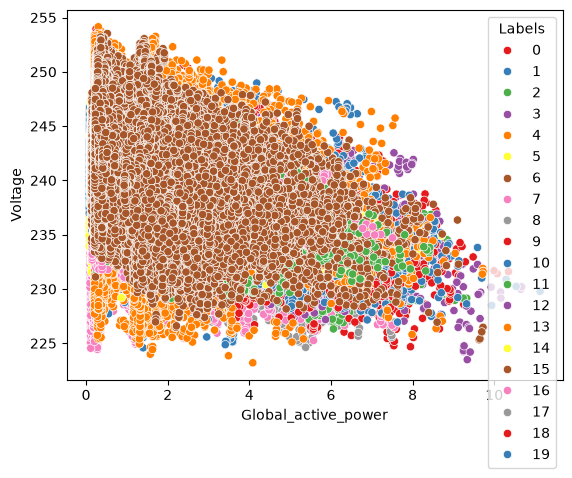

Execution time: 36.35542964935303 seconds
KMeans seaborn is finished. Run clust_seaborn.plotting !


In [3]:
clust_seaborn.main()
print("KMeans seaborn is finished. Run clust_seaborn.plotting !")